## 1. Package Imports

Load the Python packages used for data handling, plotting, correlation tests, and VAR analysis.


In [ ]:
from pathlib import Path

import numpy as np
import openpyxl
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import statsmodels

from IPython.display import display, HTML
from scipy.stats import norm, pearsonr
from sklearn.decomposition import PCA
from statsmodels.tsa.api import VAR

print("All packages imported successfully.")


## 2. Data Merging

Read stock price CSV files and the monthly sentiment Excel file, clean them, merge by month, and export the merged dataset.


In [125]:
# Project paths
PROJECT_ROOT = Path(r"C:\Users\20945\Desktop\data\project")
DATA_DIR = PROJECT_ROOT / "dataset"
STOCK_DIR = DATA_DIR / "stock"
OUTPUT_PATH = PROJECT_ROOT / "dataset" / "outputs" / "stock_sentiment_dataset.xlsx"

# Input files
STOCK_FILES = {
    "shanghai_price": STOCK_DIR / "Shanghai Composite Historical Results Price Data (1).csv",
    "nikkei_price": STOCK_DIR / "Nikkei 225 Historical Results Price Data (1).csv",
    "kospi_price": STOCK_DIR / "KOSPI Historical Results Price Data (1).csv",
    "hang_seng_price": STOCK_DIR / "Hang Seng Historical Results Price Data (1).csv",
    "singapore_sti_price": STOCK_DIR / "FTSE Straits Times Singapore Historical Results Price Data (2).csv",
}

SENTIMENT_FILE = DATA_DIR / "Investor_Sentiment_Monthly.xlsx.xlsx"

# Settings
CUTOFF_MONTH = "2023-08"
SENTIMENT_COLUMNS = ["month", "DCEF", "RIPO", "NIPO", "NA", "TURN", "CCI", "ISI", "StdISI"]


def load_stock_price(file_path: Path, price_column_name: str) -> pd.DataFrame:
    stock = pd.read_csv(file_path)

    # Parse stock dates as dd/mm/yyyy
    stock["Date"] = pd.to_datetime(stock["Date"], format="%d/%m/%Y")

    # Convert to monthly format YYYY-MM
    stock["month"] = stock["Date"].dt.strftime("%Y-%m")

    # Keep only observations up to 2023-08 and only the Price column
    stock = stock.loc[
        stock["month"] <= CUTOFF_MONTH,
        ["month", "Price"]
    ].copy()

    # Rename Price column
    stock = stock.rename(columns={"Price": price_column_name})

    # Sort by month
    stock = stock.sort_values("month").reset_index(drop=True)

    return stock


def load_sentiment(file_path: Path) -> pd.DataFrame:
    sentiment = pd.read_excel(file_path, sheet_name="sheet1")

    # Remove first two metadata/unit rows
    sentiment = sentiment.iloc[2:].copy()

    # Rename monthly date column
    sentiment = sentiment.rename(columns={"SgnMonth": "month"})

    # Convert to monthly format YYYY-MM
    sentiment["month"] = pd.to_datetime(
        sentiment["month"],
        format="%Y-%m"
    ).dt.strftime("%Y-%m")

    # Keep only required sentiment variables
    sentiment = sentiment[SENTIMENT_COLUMNS].copy()

    # Convert sentiment variables to numeric
    for column in SENTIMENT_COLUMNS[1:]:
        sentiment[column] = pd.to_numeric(sentiment[column], errors="coerce")

    sentiment = sentiment.sort_values("month").reset_index(drop=True)

    return sentiment


# Read and clean stock datasets
stock_dataframes = [
    load_stock_price(file_path, price_column_name)
    for price_column_name, file_path in STOCK_FILES.items()
]

# Merge stock datasets
master_df = stock_dataframes[0]

for stock_df in stock_dataframes[1:]:
    master_df = master_df.merge(stock_df, on="month", how="inner")

# Read and clean sentiment dataset
sentiment_df = load_sentiment(SENTIMENT_FILE)

# Merge stock data with sentiment data
master_df = master_df.merge(sentiment_df, on="month", how="inner")

# Sort final dataset
master_df = master_df.sort_values("month").reset_index(drop=True)

# Export final dataset
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
master_df.to_excel(OUTPUT_PATH, index=False)

# Notebook outputs
print(f"Exported master dataset to: {OUTPUT_PATH}")

print(f"\nFinal row count: {len(master_df):,}")
print(f"Date range: {master_df['month'].min()} to {master_df['month'].max()}")

print("\nMissing value summary:")
print(master_df.isna().sum())

print("\nColumn names:")
print(list(master_df.columns))

# Show first few rows
master_df.head()

Exported master dataset to: C:\Users\20945\Desktop\data\project\outputs\stock_sentiment_dataset.xlsx

Final row count: 248
Date range: 2003-01 to 2023-08

Missing value summary:
month                  0
shanghai_price         0
nikkei_price           0
kospi_price            0
hang_seng_price        0
singapore_sti_price    0
DCEF                   0
RIPO                   0
NIPO                   0
NA                     0
TURN                   0
CCI                    0
ISI                    0
StdISI                 0
dtype: int64

Column names:
['month', 'shanghai_price', 'nikkei_price', 'kospi_price', 'hang_seng_price', 'singapore_sti_price', 'DCEF', 'RIPO', 'NIPO', 'NA', 'TURN', 'CCI', 'ISI', 'StdISI']


,month,shanghai_price,nikkei_price,kospi_price,hang_seng_price,singapore_sti_price,DCEF,RIPO,NIPO,NA,TURN,CCI,ISI,StdISI
0,2003-01,"1,499.82","8,339.94",591.86,"9,258.95","1,253.98",-0.1034,0.9050,5,3.97,0.1054,97.5,26.44,-1.26
1,2003-02,"1,511.93","8,363.04",575.43,"9,122.66","1,236.36",-0.1117,0.7691,3,2.85,0.1928,97.7,25.30,-1.05
2,2003-03,"1,510.58","7,972.71",535.70,"8,634.45","1,235.25",-0.0941,0.6831,6,3.26,0.1328,97.8,26.20,-1.27
3,2003-04,"1,521.44","7,831.42",599.35,"8,717.22","1,251.60",-0.1399,1.1853,5,5.69,0.1218,97.6,27.69,-1.07
4,2003-05,"1,576.26","8,424.51",633.42,"9,487.38","1,324.56",-0.1892,1.0623,2,4.21,0.3197,88.7,24.05,-0.70


## 3. Return Construction

Convert stock price columns to numeric values, calculate monthly log returns, and create the analysis dataset.


In [126]:
# Convert stock price columns from string to numeric
price_vars = [
    "shanghai_price",
    "nikkei_price",
    "kospi_price",
    "hang_seng_price",
    "singapore_sti_price"
]

for col in price_vars:
    master_df[col] = (
        master_df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )

# Generate monthly log return variables
master_df["r_shanghai"] = np.log(master_df["shanghai_price"] / master_df["shanghai_price"].shift(1)) * 100
master_df["r_nikkei"] = np.log(master_df["nikkei_price"] / master_df["nikkei_price"].shift(1)) * 100
master_df["r_kospi"] = np.log(master_df["kospi_price"] / master_df["kospi_price"].shift(1)) * 100
master_df["r_hangseng"] = np.log(master_df["hang_seng_price"] / master_df["hang_seng_price"].shift(1)) * 100
master_df["r_singapore"] = np.log(master_df["singapore_sti_price"] / master_df["singapore_sti_price"].shift(1)) * 100

# Create analysis dataset and remove missing values
analysis_vars = [
    "month",
    "shanghai_price",
    "nikkei_price",
    "kospi_price",
    "hang_seng_price",
    "singapore_sti_price",
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "DCEF",
    "RIPO",
    "NIPO",
    "NA",
    "TURN",
    "CCI",
    "ISI",
    "StdISI"
]

analysis_df = master_df[analysis_vars].dropna().copy()
analysis_df["month_dt"] = pd.to_datetime(analysis_df["month"])

print(f"Rows before dropping missing values: {len(master_df)}")
print(f"Rows after dropping missing values: {len(analysis_df)}")
print(f"Date range: {analysis_df['month'].min()} to {analysis_df['month'].max()}")

analysis_df.head()

Rows before dropping missing values: 248
Rows after dropping missing values: 247
Date range: 2003-02 to 2023-08


,month,shanghai_price,nikkei_price,kospi_price,hang_seng_price,singapore_sti_price,r_shanghai,r_nikkei,r_kospi,r_hangseng,r_singapore,DCEF,RIPO,NIPO,NA,TURN,CCI,ISI,StdISI,month_dt
1,2003-02,1511.93,8363.04,575.43,9122.66,1236.36,0.804188,0.276598,-2.815253,-1.482922,-1.415091,-0.1117,0.7691,3,2.85,0.1928,97.7,25.30,-1.05,2003-02-01
2,2003-03,1510.58,7972.71,535.70,8634.45,1235.25,-0.089330,-4.779754,-7.154328,-5.500141,-0.089820,-0.0941,0.6831,6,3.26,0.1328,97.8,26.20,-1.27,2003-03-01
3,2003-04,1521.44,7831.42,599.35,8717.22,1251.60,0.716357,-1.788061,11.227143,0.954036,1.314935,-0.1399,1.1853,5,5.69,0.1218,97.6,27.69,-1.07,2003-04-01
4,2003-05,1576.26,8424.51,633.42,9487.38,1324.56,3.539770,7.300147,5.528797,8.466211,5.665760,-0.1892,1.0623,2,4.21,0.3197,88.7,24.05,-0.70,2003-05-01
5,2003-06,1486.02,9083.11,669.93,9577.12,1425.24,-5.895355,7.527133,5.603952,0.941443,7.325989,-0.1962,0.8507,7,5.35,0.2558,85.7,25.10,-1.11,2003-06-01


## 4. Descriptive Statistics

Summarize the monthly return variables.


In [127]:
return_vars = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore"
]

summary_returns = pd.DataFrame({
    "Obs": analysis_df[return_vars].count(),
    "Mean": analysis_df[return_vars].mean(),
    "Std. dev.": analysis_df[return_vars].std(ddof=1),
    "Min": analysis_df[return_vars].min(),
    "Max": analysis_df[return_vars].max()
})

summary_returns = summary_returns.reset_index().rename(columns={"index": "Variable"})

summary_returns

,Variable,Obs,Mean,Std. dev.,Min,Max
0,r_shanghai,247,0.296538,7.327552,-28.277937,24.252587
1,r_nikkei,247,0.552166,5.332271,-27.216232,14.013731
2,r_kospi,247,0.592322,5.402741,-26.311175,13.365158
3,r_hangseng,247,0.277646,6.403286,-25.445494,23.604853
4,r_singapore,247,0.383474,4.829061,-27.364041,19.300233


## 5. EDA: StdISI Time Series

Plot the standardized investor sentiment index over time.


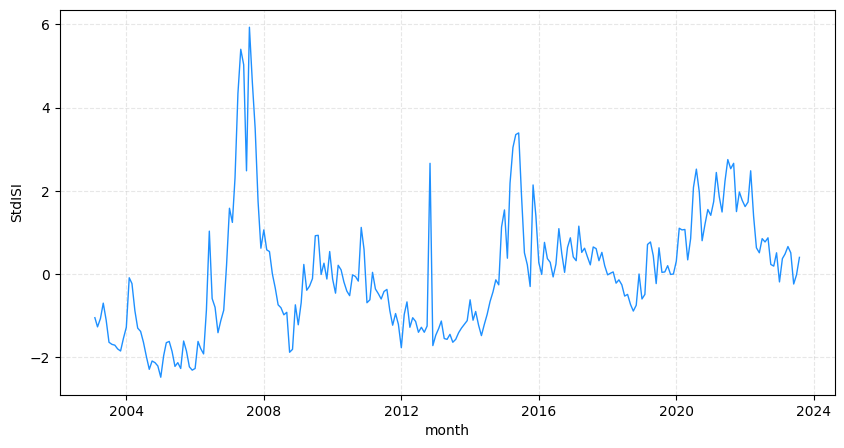

In [128]:
plt.figure(figsize=(10, 5))
plt.plot(analysis_df["month_dt"], analysis_df["StdISI"], color="dodgerblue", linewidth=1)
plt.xlabel("month")
plt.ylabel("StdISI")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

## 6. EDA: Shanghai Return and StdISI

Compare Shanghai monthly returns with standardized investor sentiment.


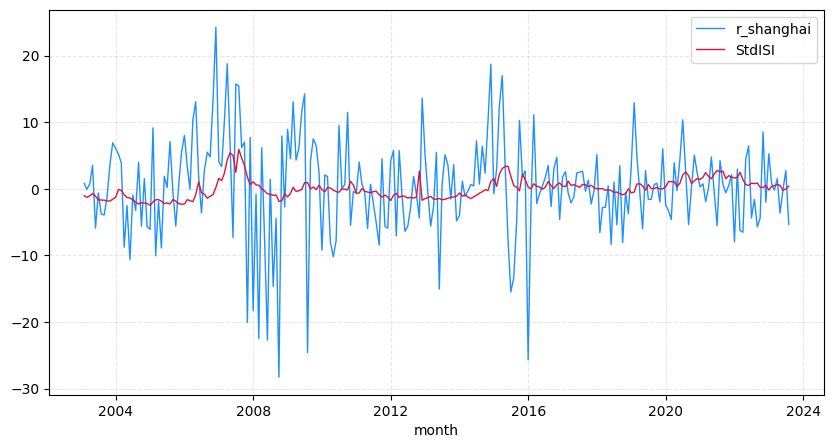

In [129]:
plt.figure(figsize=(10, 5))
plt.plot(analysis_df["month_dt"], analysis_df["r_shanghai"], label="r_shanghai", color="dodgerblue", linewidth=1)
plt.plot(analysis_df["month_dt"], analysis_df["StdISI"], label="StdISI", color="crimson", linewidth=1)
plt.xlabel("month")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

## 7. EDA: Shanghai Return and ISI

Compare Shanghai monthly returns with the original investor sentiment index.


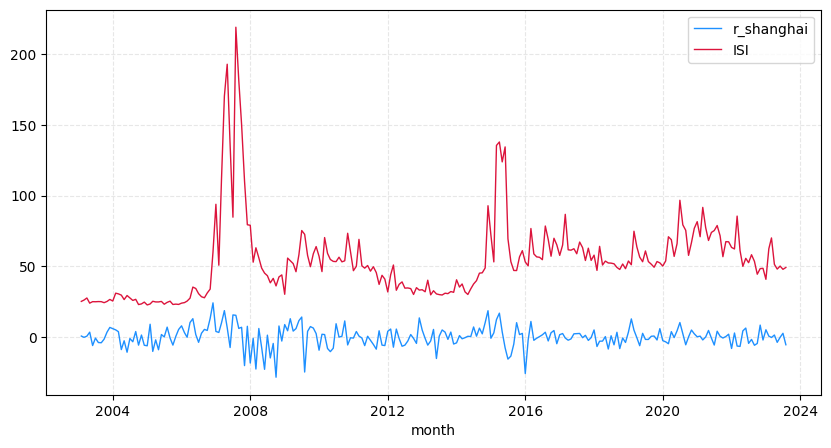

In [130]:
plt.figure(figsize=(10, 5))
plt.plot(analysis_df["month_dt"], analysis_df["r_shanghai"], label="r_shanghai", color="dodgerblue", linewidth=1)
plt.plot(analysis_df["month_dt"], analysis_df["ISI"], label="ISI", color="crimson", linewidth=1)
plt.xlabel("month")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

## 8. EDA: Shanghai Price and ISI

Compare Shanghai index price with the original investor sentiment index.


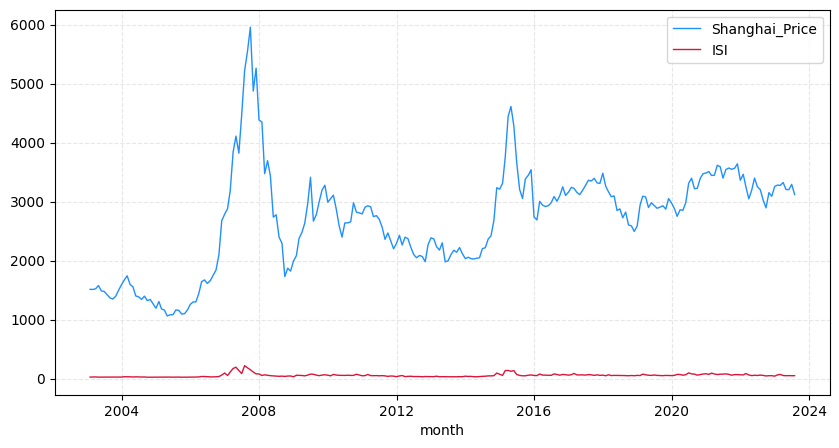

In [131]:
plt.figure(figsize=(10, 5))
plt.plot(analysis_df["month_dt"], analysis_df["shanghai_price"], label="Shanghai_Price", color="dodgerblue", linewidth=1)
plt.plot(analysis_df["month_dt"], analysis_df["ISI"], label="ISI", color="crimson", linewidth=1)
plt.xlabel("month")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

## 9. Correlation Table Function

Define a reusable HTML correlation table with p-values and significance stars.


In [132]:
def correlation_table_html(df, variables, star_level=0.05):
    corr_display = pd.DataFrame("", index=variables, columns=variables)

    for row_var in variables:
        for col_var in variables:
            row_index = variables.index(row_var)
            col_index = variables.index(col_var)

            # Only show the lower triangle.
            if col_index > row_index:
                continue

            if row_var == col_var:
                corr_display.loc[row_var, col_var] = "1.0000"
            else:
                temp = df[[row_var, col_var]].dropna()
                corr, p_value = pearsonr(temp[row_var], temp[col_var])

                star = "*" if p_value < star_level else ""
                corr_display.loc[row_var, col_var] = (
                    f"{corr:.4f}{star}<br>"
                    f"{p_value:.4f}"
                )

    html = corr_display.to_html(escape=False)
    display(HTML(html))

    return corr_display


## 10. Correlation: Returns and StdISI

Compute pairwise correlations between market returns and StdISI.


In [133]:
corr_vars_stdisi = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "StdISI"
]

corr_stdisi_table = correlation_table_html(
    analysis_df,
    corr_vars_stdisi,
    star_level=0.05
)


,r_shanghai,r_nikkei,r_kospi,r_hangseng,r_singapore,StdISI
r_shanghai,1.0000,,,,,
r_nikkei,0.3477*0.0000,1.0000,,,,
r_kospi,0.4113*0.0000,0.6068*0.0000,1.0000,,,
r_hangseng,0.5592*0.0000,0.4680*0.0000,0.5589*0.0000,1.0000,,
r_singapore,0.4491*0.0000,0.6292*0.0000,0.6957*0.0000,0.7031*0.0000,1.0000,
StdISI,0.10790.0906,-0.02140.7385,0.02710.6714,-0.01080.8659,0.00020.9972,1.0000


## 11. Correlation: Returns and ISI

Compute pairwise correlations between market returns and ISI.


In [134]:
corr_vars_isi = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "ISI"
]

corr_isi_table = correlation_table_html(
    analysis_df,
    corr_vars_isi,
    star_level=0.05
)


,r_shanghai,r_nikkei,r_kospi,r_hangseng,r_singapore,ISI
r_shanghai,1.0000,,,,,
r_nikkei,0.3477*0.0000,1.0000,,,,
r_kospi,0.4113*0.0000,0.6068*0.0000,1.0000,,,
r_hangseng,0.5592*0.0000,0.4680*0.0000,0.5589*0.0000,1.0000,,
r_singapore,0.4491*0.0000,0.6292*0.0000,0.6957*0.0000,0.7031*0.0000,1.0000,
ISI,0.1824*0.0040,-0.04360.4955,0.05130.4222,0.05590.3814,0.01130.8593,1.0000


## 12. VAR Lag Selection: ISI, Max Lag 4

Select lag order for the VAR model using returns and ISI with maximum lag 4.


In [135]:
# ISI VAR lag-order selection with maximum lag 4.
var_vars_isi = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "ISI"
]

var_data_isi = analysis_df[var_vars_isi].dropna().copy()
var_model_isi = VAR(var_data_isi)

lag_order_isi_4 = var_model_isi.select_order(maxlags=4)
lag_order_isi_4.summary()


,AIC,BIC,FPE,HQIC
0,21.88,21.96,3.175e+09,21.91
1,20.62,21.23*,9.058e+08,20.87*
2,20.60,21.72,8.865e+08,21.05
3,20.62,22.26,9.018e+08,21.28
4,20.58*,22.73,8.687e+08*,21.45


## 13. VAR Lag Selection: ISI, Max Lag 6

Repeat lag-order selection for the ISI model with maximum lag 6.


In [136]:
# ISI VAR lag-order selection with maximum lag 6.
var_vars_isi = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "ISI"
]

var_data_isi = analysis_df[var_vars_isi].dropna().copy()
var_model_isi = VAR(var_data_isi)

lag_order_isi_6 = var_model_isi.select_order(maxlags=6)
lag_order_isi_6.summary()


,AIC,BIC,FPE,HQIC
0,21.89,21.97,3.200e+09,21.92
1,20.65,21.25*,9.251e+08,20.89*
2,20.62,21.75,9.041e+08,21.08
3,20.64,22.29,9.235e+08,21.31
4,20.60*,22.77,8.867e+08*,21.47
5,20.63,23.32,9.190e+08,21.71
6,20.77,23.98,1.068e+09,22.07


## 14. VAR Lag Selection: StdISI, Max Lag 6

Select lag order for the VAR model using returns and StdISI with maximum lag 6.


In [137]:
# StdISI VAR lag-order selection with maximum lag 6.
var_vars_stdisi = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "StdISI"
]

var_data_stdisi = analysis_df[var_vars_stdisi].dropna().copy()
var_model_stdisi = VAR(var_data_stdisi)

lag_order_stdisi_6 = var_model_stdisi.select_order(maxlags=6)
lag_order_stdisi_6.summary()


,AIC,BIC,FPE,HQIC
0,15.99,16.08,8.834e+06,16.03
1,14.42,15.03*,1.831e+06,14.67*
2,14.40*,15.53,1.802e+06*,14.86
3,14.49,16.14,1.975e+06,15.16
4,14.43,16.60,1.861e+06,15.31
5,14.46,17.15,1.930e+06,15.55
6,14.61,17.82,2.239e+06,15.90


## 15. VAR(2) Model with StdISI

Estimate the VAR model with two lags using market returns and StdISI.


In [138]:
# Estimate the VAR(2) model with StdISI.
var_vars_stdisi = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "StdISI"
]

var_data_stdisi = analysis_df[var_vars_stdisi].dropna().copy()
var_model_stdisi = VAR(var_data_stdisi)

# fit(2) includes lag 1 and lag 2.
var_results_stdisi_lag2 = var_model_stdisi.fit(2)

print(var_results_stdisi_lag2.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 04, Jun, 2026
Time:                     00:50:44
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                    15.4958
Nobs:                     245.000    HQIC:                   14.8300
Log likelihood:          -3769.53    FPE:                1.76161e+06
AIC:                      14.3811    Det(Omega_mle):     1.29178e+06
--------------------------------------------------------------------
Results for equation r_shanghai
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.222186         0.475252            0.468           0.640
L1.r_shanghai          0.112169         0.080740            1.389           0.165
L1.r_nikkei           -0.078217         0.120835   

## 16. Full VAR Coefficient Table

Create a complete coefficient table for the VAR(2) model.


In [139]:
# Complete coefficient table for the VAR(2) model.
params = var_results_stdisi_lag2.params
stderr = var_results_stdisi_lag2.stderr
zvalues = var_results_stdisi_lag2.tvalues
pvalues = var_results_stdisi_lag2.pvalues

z_crit = norm.ppf(0.975)

base_variables = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "StdISI"
]

ordered_parameters = []
for base_var in base_variables:
    ordered_parameters.append(f"L1.{base_var}")
    ordered_parameters.append(f"L2.{base_var}")
ordered_parameters.append("const")

rows = []

for equation in params.columns:
    for variable in ordered_parameters:
        if variable not in params.index:
            continue

        coef = params.loc[variable, equation]
        se = stderr.loc[variable, equation]
        z = zvalues.loc[variable, equation]
        p = pvalues.loc[variable, equation]
        ci_lower = coef - z_crit * se
        ci_upper = coef + z_crit * se

        if variable == "const":
            lag = "const"
            variable_name = "const"
        else:
            lag, variable_name = variable.split(".", 1)

        rows.append({
            "Equation": equation,
            "Variable": variable_name,
            "Lag": lag,
            "Coefficient": coef,
            "Std. err.": se,
            "z": z,
            "P>|z|": p,
            "95% CI lower": ci_lower,
            "95% CI upper": ci_upper
        })

var_stdisi_lag2_full_table = pd.DataFrame(rows)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

display(var_stdisi_lag2_full_table)


,Equation,Variable,Lag,Coefficient,Std. err.,z,P>|z|,95% CI lower,95% CI upper
0,r_shanghai,r_shanghai,L1,0.112169,0.080740,1.389262,1.647531e-01,-0.046078,0.270415
1,r_shanghai,r_shanghai,L2,0.138769,0.089625,1.548332,1.215425e-01,-0.036892,0.314430
2,r_shanghai,r_nikkei,L1,-0.078217,0.120835,-0.647305,5.174344e-01,-0.315048,0.158615
3,r_shanghai,r_nikkei,L2,-0.258566,0.122264,-2.114813,3.444591e-02,-0.498199,-0.018932
4,r_shanghai,r_kospi,L1,0.031788,0.130903,0.242838,8.081307e-01,-0.224778,0.288354
5,r_shanghai,r_kospi,L2,0.125476,0.129869,0.966168,3.339599e-01,-0.129064,0.380015
6,r_shanghai,r_hangseng,L1,-0.038283,0.116887,-0.327518,7.432760e-01,-0.267377,0.190812
7,r_shanghai,r_hangseng,L2,-0.047529,0.112821,-0.421274,6.735550e-01,-0.268655,0.173597
8,r_shanghai,r_singapore,L1,0.070577,0.172441,0.409284,6.823315e-01,-0.267401,0.408555
9,r_shanghai,r_singapore,L2,0.239378,0.168016,1.424735,1.542338e-01,-0.089927,0.568683


## 17. VAR Stability Test

Check whether the estimated VAR model satisfies the stability condition.


In [140]:
# Stability test using companion-matrix eigenvalues.
# The VAR is stable when all eigenvalue moduli are less than 1.
eigenvalues = 1 / var_results_stdisi_lag2.roots

stability_table = pd.DataFrame({
    "Eigenvalue": eigenvalues,
    "Modulus": np.abs(eigenvalues)
})

stability_table = stability_table.sort_values(
    by="Modulus",
    ascending=False
).reset_index(drop=True)

display(stability_table)

if np.all(stability_table["Modulus"] < 1):
    print("All eigenvalue moduli are less than 1.")
    print("VAR satisfies stability condition.")
else:
    print("At least one eigenvalue modulus is greater than or equal to 1.")
    print("VAR does not satisfy stability condition.")


,Eigenvalue,Modulus
0,0.882698+0.000000j,0.882698
1,-0.107598-0.544328j,0.554860
2,-0.107598+0.544328j,0.554860
3,-0.405282-0.033640j,0.406675
4,-0.405282+0.033640j,0.406675
5,0.371653-0.041134j,0.373923
6,0.371653+0.041134j,0.373923
7,0.020774-0.258450j,0.259283
8,0.020774+0.258450j,0.259283
9,-0.199688-0.000000j,0.199688


All eigenvalue moduli are less than 1.
VAR satisfies stability condition.


## 18. Granger Causality Tests

Run Wald tests for Granger causality among the VAR variables.


In [141]:
# Granger causality Wald tests using statsmodels.
var_names = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "StdISI"
]

granger_rows = []

for equation in var_names:
    excluded_vars = [var for var in var_names if var != equation]

    # Test each excluded variable one by one.
    for excluded in excluded_vars:
        test_result = var_results_stdisi_lag2.test_causality(
            caused=equation,
            causing=excluded,
            kind="wald"
        )

        granger_rows.append({
            "Equation": equation,
            "Excluded": excluded,
            "chi2": test_result.test_statistic,
            "df": test_result.df,
            "Prob > chi2": test_result.pvalue
        })

    # Test all other variables jointly.
    test_all = var_results_stdisi_lag2.test_causality(
        caused=equation,
        causing=excluded_vars,
        kind="wald"
    )

    granger_rows.append({
        "Equation": equation,
        "Excluded": "ALL",
        "chi2": test_all.test_statistic,
        "df": test_all.df,
        "Prob > chi2": test_all.pvalue
    })

granger_table = pd.DataFrame(granger_rows)

granger_table_formatted = granger_table.copy()
granger_table_formatted["chi2"] = granger_table_formatted["chi2"].map(lambda x: f"{x:.4f}")
granger_table_formatted["Prob > chi2"] = granger_table_formatted["Prob > chi2"].map(lambda x: f"{x:.3f}")

display(granger_table_formatted)


,Equation,Excluded,chi2,df,Prob > chi2
0,r_shanghai,r_nikkei,4.9368,2,0.085
1,r_shanghai,r_kospi,0.9621,2,0.618
2,r_shanghai,r_hangseng,0.2601,2,0.878
3,r_shanghai,r_singapore,2.1559,2,0.340
4,r_shanghai,StdISI,1.3418,2,0.511
5,r_shanghai,ALL,7.7945,10,0.649
6,r_nikkei,r_shanghai,3.2733,2,0.195
7,r_nikkei,r_kospi,1.3578,2,0.507
8,r_nikkei,r_hangseng,0.5467,2,0.761
9,r_nikkei,r_singapore,0.0217,2,0.989


## 19. VAR(4) Model with StdISI

Estimate the VAR model with four lags using market returns and StdISI.


In [ ]:
# Estimate the VAR(4) model with StdISI.
var_vars_stdisi = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "StdISI"
]

var_data_stdisi = analysis_df[var_vars_stdisi].dropna().copy()
var_model_stdisi = VAR(var_data_stdisi)

# fit(4) includes lag 1, lag 2, lag 3, and lag 4.
var_results_stdisi_lag4 = var_model_stdisi.fit(4)

print(var_results_stdisi_lag4.summary())


## 20. Full VAR(4) Coefficient Table

Create a complete coefficient table for the VAR(4) model.


In [143]:
# Complete coefficient table for the VAR(4) model.
params = var_results_stdisi_lag4.params
stderr = var_results_stdisi_lag4.stderr
zvalues = var_results_stdisi_lag4.tvalues
pvalues = var_results_stdisi_lag4.pvalues

z_crit = norm.ppf(0.975)

base_variables = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "StdISI"
]

ordered_parameters = []
for base_var in base_variables:
    for lag_number in range(1, 5):
        ordered_parameters.append(f"L{lag_number}.{base_var}")
ordered_parameters.append("const")

rows = []

for equation in params.columns:
    for variable in ordered_parameters:
        if variable not in params.index:
            continue

        coef = params.loc[variable, equation]
        se = stderr.loc[variable, equation]
        z = zvalues.loc[variable, equation]
        p = pvalues.loc[variable, equation]
        ci_lower = coef - z_crit * se
        ci_upper = coef + z_crit * se

        if variable == "const":
            lag = "const"
            variable_name = "const"
        else:
            lag, variable_name = variable.split(".", 1)

        rows.append({
            "Equation": equation,
            "Variable": variable_name,
            "Lag": lag,
            "Coefficient": coef,
            "Std. err.": se,
            "z": z,
            "P>|z|": p,
            "95% CI lower": ci_lower,
            "95% CI upper": ci_upper
        })

var_stdisi_lag4_full_table = pd.DataFrame(rows)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

display(var_stdisi_lag4_full_table)


,Equation,Variable,Lag,Coefficient,Std. err.,z,P>|z|,95% CI lower,95% CI upper
0,r_shanghai,r_shanghai,L1,0.105026,0.079782,1.316415,1.880349e-01,-0.051344,0.261395
1,r_shanghai,r_shanghai,L2,0.159362,0.094675,1.683259,9.232500e-02,-0.026197,0.344921
2,r_shanghai,r_shanghai,L3,0.044914,0.094335,0.476108,6.339975e-01,-0.139980,0.229808
3,r_shanghai,r_shanghai,L4,0.363120,0.089687,4.048767,5.148816e-05,0.187337,0.538902
4,r_shanghai,r_nikkei,L1,-0.116411,0.120665,-0.964749,3.346704e-01,-0.352909,0.120087
5,r_shanghai,r_nikkei,L2,-0.268877,0.122595,-2.193209,2.829235e-02,-0.509160,-0.028595
6,r_shanghai,r_nikkei,L3,-0.102295,0.125615,-0.814359,4.154393e-01,-0.348495,0.143905
7,r_shanghai,r_nikkei,L4,0.048904,0.125505,0.389657,6.967904e-01,-0.197082,0.294890
8,r_shanghai,r_kospi,L1,0.079250,0.135911,0.583099,5.598263e-01,-0.187131,0.345631
9,r_shanghai,r_kospi,L2,0.167953,0.133897,1.254346,2.097162e-01,-0.094480,0.430385


## 21. VAR(4) Stability Test

Check whether the VAR(4) model satisfies the stability condition.


In [144]:
# Stability test using companion-matrix eigenvalues.
# The VAR is stable when all eigenvalue moduli are less than 1.
eigenvalues_lag4 = 1 / var_results_stdisi_lag4.roots

stability_table_lag4 = pd.DataFrame({
    "Eigenvalue": eigenvalues_lag4,
    "Modulus": np.abs(eigenvalues_lag4)
})

stability_table_lag4 = stability_table_lag4.sort_values(
    by="Modulus",
    ascending=False
).reset_index(drop=True)

display(stability_table_lag4)

if np.all(stability_table_lag4["Modulus"] < 1):
    print("All eigenvalue moduli are less than 1.")
    print("VAR(4) satisfies stability condition.")
else:
    print("At least one eigenvalue modulus is greater than or equal to 1.")
    print("VAR(4) does not satisfy stability condition.")


,Eigenvalue,Modulus
0,0.859690+0.000000j,0.859690
1,0.764000+0.000000j,0.764000
2,-0.395392-0.650287j,0.761057
3,-0.395392+0.650287j,0.761057
4,0.030069-0.725058j,0.725681
5,0.030069+0.725058j,0.725681
6,0.140029-0.697939j,0.711848
7,0.140029+0.697939j,0.711848
8,-0.651852-0.000000j,0.651852
9,-0.342665-0.537365j,0.637323


All eigenvalue moduli are less than 1.
VAR(4) satisfies stability condition.


## 22. VAR(4) Granger Causality Tests

Run Wald tests for Granger causality using the VAR(4) model.


In [145]:
# Granger causality Wald tests using the VAR(4) model.
var_names = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "StdISI"
]

granger_lag4_rows = []

for equation in var_names:
    excluded_vars = [var for var in var_names if var != equation]

    # Test each excluded variable one by one.
    for excluded in excluded_vars:
        test_result = var_results_stdisi_lag4.test_causality(
            caused=equation,
            causing=excluded,
            kind="wald"
        )

        granger_lag4_rows.append({
            "Equation": equation,
            "Excluded": excluded,
            "chi2": test_result.test_statistic,
            "df": test_result.df,
            "Prob > chi2": test_result.pvalue
        })

    # Test all other variables jointly.
    test_all = var_results_stdisi_lag4.test_causality(
        caused=equation,
        causing=excluded_vars,
        kind="wald"
    )

    granger_lag4_rows.append({
        "Equation": equation,
        "Excluded": "ALL",
        "chi2": test_all.test_statistic,
        "df": test_all.df,
        "Prob > chi2": test_all.pvalue
    })

granger_lag4_table = pd.DataFrame(granger_lag4_rows)

granger_lag4_table_formatted = granger_lag4_table.copy()
granger_lag4_table_formatted["chi2"] = granger_lag4_table_formatted["chi2"].map(lambda x: f"{x:.4f}")
granger_lag4_table_formatted["Prob > chi2"] = granger_lag4_table_formatted["Prob > chi2"].map(lambda x: f"{x:.3f}")

display(granger_lag4_table_formatted)


,Equation,Excluded,chi2,df,Prob > chi2
0,r_shanghai,r_nikkei,6.4942,4,0.165
1,r_shanghai,r_kospi,11.1560,4,0.025
2,r_shanghai,r_hangseng,1.9237,4,0.750
3,r_shanghai,r_singapore,3.9483,4,0.413
4,r_shanghai,StdISI,5.9803,4,0.201
5,r_shanghai,ALL,26.9324,20,0.137
6,r_nikkei,r_shanghai,11.1150,4,0.025
7,r_nikkei,r_kospi,10.2805,4,0.036
8,r_nikkei,r_hangseng,3.2764,4,0.513
9,r_nikkei,r_singapore,2.0220,4,0.732


## 23. Standardize Sentiment Variables

Create standardized sentiment variables for PCA.


In [ ]:
# Sentiment variables used for PCA.
sentiment_pca_vars = ["DCEF", "RIPO", "NIPO", "NA", "TURN", "CCI"]

# Use the full merged monthly dataset for PCA because these sentiment variables
# do not lose the first return observation.
pca_df = master_df[["month"] + sentiment_pca_vars].copy()

for col in sentiment_pca_vars:
    pca_df[f"z_{col}"] = (
        pca_df[col] - pca_df[col].mean()
    ) / pca_df[col].std(ddof=1)

z_sentiment_vars = [f"z_{col}" for col in sentiment_pca_vars]

print(f"PCA observations: {len(pca_df)}")
print("Standardized variables:")
print(z_sentiment_vars)

pca_df[["month"] + z_sentiment_vars].head()


## 24. PCA for Sentiment Variables

Run PCA using the standardized sentiment variables and report eigenvalues, explained variance, and loadings.


In [159]:
# PCA on standardized sentiment variables.
X_pca = pca_df[z_sentiment_vars].dropna().copy()

pca_model = PCA()
pca_scores = pca_model.fit_transform(X_pca)

component_names = [f"Comp{i}" for i in range(1, len(z_sentiment_vars) + 1)]

eigenvalues = pca_model.explained_variance_
proportion = pca_model.explained_variance_ratio_
cumulative = np.cumsum(proportion)
difference = np.r_[eigenvalues[:-1] - eigenvalues[1:], np.nan]

pca_summary = pd.DataFrame({
    "Component": component_names,
    "Eigenvalue": eigenvalues,
    "Difference": difference,
    "Proportion": proportion,
    "Cumulative": cumulative
})

loadings = pd.DataFrame(
    pca_model.components_.T,
    index=z_sentiment_vars,
    columns=component_names
)

print(f"Number of obs: {len(X_pca)}")
print(f"Number of components: {len(component_names)}")
print(f"Trace: {eigenvalues.sum():.4f}")

print("\nPCA summary:")
display(pca_summary)

print("\nPCA loadings:")
display(loadings)


Number of obs: 248
Number of components: 6
Trace: 6.0000

PCA summary:


,Component,Eigenvalue,Difference,Proportion,Cumulative
0,Comp1,2.011522,0.386965,0.335254,0.335254
1,Comp2,1.624557,0.753347,0.270759,0.606013
2,Comp3,0.871209,0.157553,0.145202,0.751215
3,Comp4,0.713657,0.291885,0.118943,0.870157
4,Comp5,0.421772,0.064488,0.070295,0.940453
5,Comp6,0.357284,NaN,0.059547,1.000000



PCA loadings:


,Comp1,Comp2,Comp3,Comp4,Comp5,Comp6
z_DCEF,0.341958,-0.511647,-0.378379,-0.254048,-0.569954,-0.297866
z_RIPO,0.382240,0.288762,0.590574,-0.570780,-0.005691,-0.309692
z_NIPO,0.492592,-0.380654,-0.175388,-0.148589,0.726318,0.179107
z_NA,0.519818,0.377823,-0.109996,0.061359,-0.335532,0.677195
z_TURN,0.325851,0.512176,-0.420775,0.343762,0.154014,-0.559064
z_CCI,0.343398,-0.323824,0.536786,0.682388,-0.106211,-0.110190


## 25. Scree Plot

Plot PCA eigenvalues and add a reference line at eigenvalue 1.


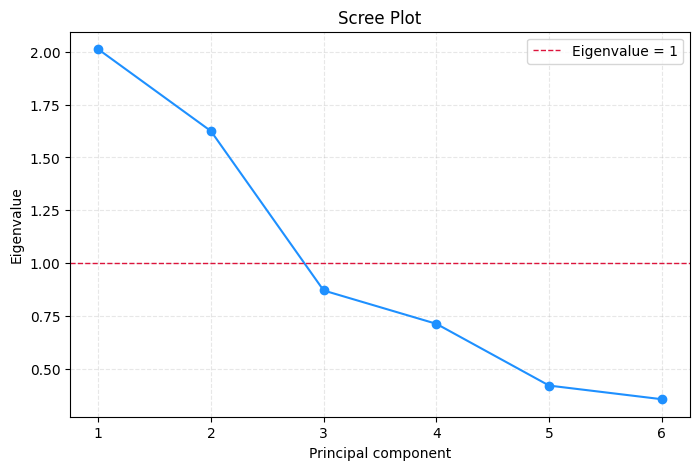

In [160]:
# Scree plot for PCA eigenvalues.
component_numbers = np.arange(1, len(eigenvalues) + 1)

plt.figure(figsize=(8, 5))
plt.plot(
    component_numbers,
    eigenvalues,
    marker="o",
    color="dodgerblue",
    linewidth=1.5
)

plt.axhline(
    y=1,
    color="crimson",
    linestyle="--",
    linewidth=1,
    label="Eigenvalue = 1"
)

plt.xticks(component_numbers)
plt.xlabel("Principal component")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.show()


## 26. PCA Loadings

Display the PCA loading matrix for the standardized sentiment variables.


In [161]:
# Display PCA loadings separately.
loadings


,Comp1,Comp2,Comp3,Comp4,Comp5,Comp6
z_DCEF,0.341958,-0.511647,-0.378379,-0.254048,-0.569954,-0.297866
z_RIPO,0.382240,0.288762,0.590574,-0.570780,-0.005691,-0.309692
z_NIPO,0.492592,-0.380654,-0.175388,-0.148589,0.726318,0.179107
z_NA,0.519818,0.377823,-0.109996,0.061359,-0.335532,0.677195
z_TURN,0.325851,0.512176,-0.420775,0.343762,0.154014,-0.559064
z_CCI,0.343398,-0.323824,0.536786,0.682388,-0.106211,-0.110190


## 27. Generate PCA1 and PCA2

Create the first two principal component score variables.


In [162]:
# Align PCA signs so higher component scores have a consistent sentiment direction.
# PCA signs are arbitrary, so multiplying a component by -1 is still the same PCA solution.
if loadings.loc["z_DCEF", "Comp1"] < 0:
    loadings["Comp1"] = -loadings["Comp1"]
    pca_scores[:, 0] = -pca_scores[:, 0]

if loadings.loc["z_DCEF", "Comp2"] < 0:
    loadings["Comp2"] = -loadings["Comp2"]
    pca_scores[:, 1] = -pca_scores[:, 1]

# Add aligned PCA scores to the PCA dataset.
pca_df["pca1"] = pca_scores[:, 0]
pca_df["pca2"] = pca_scores[:, 1]

pca_df[["month", "pca1", "pca2"]].head()


,month,pca1,pca2
0,2003-01,-1.228350,0.422810
1,2003-02,-1.164926,0.051236
2,2003-03,-1.225578,0.479150
3,2003-04,-1.097114,0.077882
4,2003-05,-1.155325,-1.206262


## 28. Construct Final Sentiment Index

Construct the final sentiment index using the first two PCA components weighted by their explained variance shares.


In [163]:
# Construct final sentiment index using PCA1 and PCA2.
pca1_weight = proportion[0]
pca2_weight = proportion[1]
total_weight = pca1_weight + pca2_weight

pca_df["sen"] = (
    (pca1_weight / total_weight) * pca_df["pca1"]
    + (pca2_weight / total_weight) * pca_df["pca2"]
)

# Merge sen back into analysis_df by month for later correlation and VAR analysis.
analysis_df = analysis_df.merge(
    pca_df[["month", "pca1", "pca2", "sen"]],
    on="month",
    how="left"
)

print(f"PCA1 weight: {pca1_weight / total_weight:.4f}")
print(f"PCA2 weight: {pca2_weight / total_weight:.4f}")

analysis_df[["month", "pca1", "pca2", "sen"]].head()


PCA1 weight: 0.5532
PCA2 weight: 0.4468


,month,pca1,pca2,sen
0,2003-02,-1.164926,0.051236,-0.621559
1,2003-03,-1.225578,0.479150,-0.463925
2,2003-04,-1.097114,0.077882,-0.572140
3,2003-05,-1.155325,-1.206262,-1.178083
4,2003-06,-1.386193,-0.853339,-1.148120


## 29. Plot Constructed Sentiment Index

Compare the constructed sentiment index with StdISI over time.


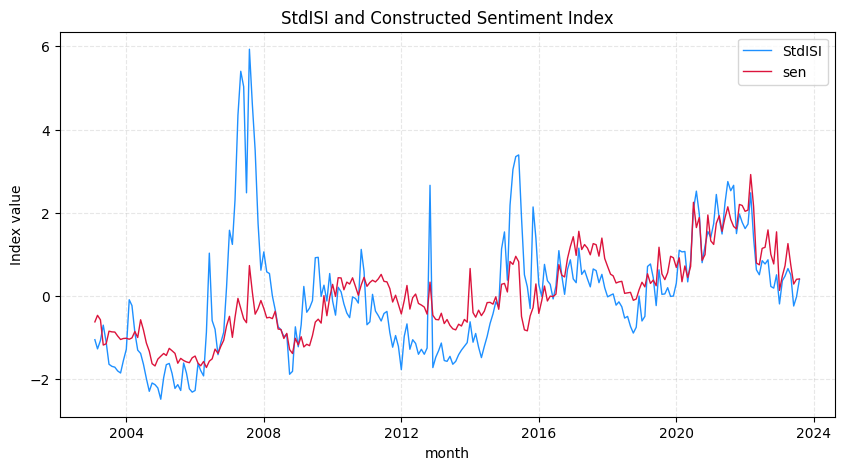

In [164]:
# Plot constructed sentiment index against StdISI.
plt.figure(figsize=(10, 5))

plt.plot(
    analysis_df["month_dt"],
    analysis_df["StdISI"],
    label="StdISI",
    color="dodgerblue",
    linewidth=1
)

plt.plot(
    analysis_df["month_dt"],
    analysis_df["sen"],
    label="sen",
    color="crimson",
    linewidth=1
)

plt.xlabel("month")
plt.ylabel("Index value")
plt.title("StdISI and Constructed Sentiment Index")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


## 30. Correlation: Returns and sen

Compute pairwise correlations between market returns and the constructed sentiment index.


In [165]:
corr_vars_sen = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "sen"
]

corr_sen_table = correlation_table_html(
    analysis_df,
    corr_vars_sen,
    star_level=0.05
)


,r_shanghai,r_nikkei,r_kospi,r_hangseng,r_singapore,sen
r_shanghai,1.0000,,,,,
r_nikkei,0.3477*0.0000,1.0000,,,,
r_kospi,0.4113*0.0000,0.6068*0.0000,1.0000,,,
r_hangseng,0.5592*0.0000,0.4680*0.0000,0.5589*0.0000,1.0000,,
r_singapore,0.4491*0.0000,0.6292*0.0000,0.6957*0.0000,0.7031*0.0000,1.0000,
sen,-0.02070.7464,-0.01410.8257,-0.06250.3277,-0.09280.1459,-0.03340.6016,1.0000


## 31. VAR Lag Selection: sen, Max Lag 6

Select lag order for the VAR model using returns and the constructed sentiment index.


In [166]:
# sen VAR lag-order selection with maximum lag 6.
var_vars_sen = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "sen"
]

var_data_sen = analysis_df[var_vars_sen].dropna().copy()
var_model_sen = VAR(var_data_sen)

lag_order_sen_6 = var_model_sen.select_order(maxlags=6)
lag_order_sen_6.summary()


,AIC,BIC,FPE,HQIC
0,15.18,15.26,3.898e+06,15.21
1,13.30,13.91*,5.967e+05,13.54*
2,13.29*,14.42,5.931e+05*,13.75
3,13.40,15.05,6.636e+05,14.07
4,13.41,15.58,6.680e+05,14.28
5,13.45,16.14,7.030e+05,14.54
6,13.60,16.81,8.184e+05,14.89


## 32. VAR(2) Model with sen

Estimate the VAR model with two lags using market returns and the constructed sentiment index.


In [167]:
# Estimate the VAR(2) model with sen.
var_vars_sen = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "sen"
]

var_data_sen = analysis_df[var_vars_sen].dropna().copy()
var_model_sen = VAR(var_data_sen)

# fit(2) includes lag 1 and lag 2.
var_results_sen_lag2 = var_model_sen.fit(2)

print(var_results_sen_lag2.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 05, Jun, 2026
Time:                     00:48:00
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                    14.3983
Nobs:                     245.000    HQIC:                   13.7325
Log likelihood:          -3635.08    FPE:                    587847.
AIC:                      13.2836    Det(Omega_mle):         431065.
--------------------------------------------------------------------
Results for equation r_shanghai
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.223811         0.474997            0.471           0.638
L1.r_shanghai          0.099709         0.080184            1.244           0.214
L1.r_nikkei           -0.062858         0.120372   

## 33. Full VAR(2) Coefficient Table with sen

Create a complete coefficient table for the VAR(2) model using sen.


In [168]:
# Complete coefficient table for the VAR(2) model with sen.
params = var_results_sen_lag2.params
stderr = var_results_sen_lag2.stderr
zvalues = var_results_sen_lag2.tvalues
pvalues = var_results_sen_lag2.pvalues

z_crit = norm.ppf(0.975)

base_variables = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "sen"
]

ordered_parameters = []
for base_var in base_variables:
    ordered_parameters.append(f"L1.{base_var}")
    ordered_parameters.append(f"L2.{base_var}")
ordered_parameters.append("const")

rows = []

for equation in params.columns:
    for variable in ordered_parameters:
        if variable not in params.index:
            continue

        coef = params.loc[variable, equation]
        se = stderr.loc[variable, equation]
        z = zvalues.loc[variable, equation]
        p = pvalues.loc[variable, equation]
        ci_lower = coef - z_crit * se
        ci_upper = coef + z_crit * se

        if variable == "const":
            lag = "const"
            variable_name = "const"
        else:
            lag, variable_name = variable.split(".", 1)

        rows.append({
            "Equation": equation,
            "Variable": variable_name,
            "Lag": lag,
            "Coefficient": coef,
            "Std. err.": se,
            "z": z,
            "P>|z|": p,
            "95% CI lower": ci_lower,
            "95% CI upper": ci_upper
        })

var_sen_lag2_full_table = pd.DataFrame(rows)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

display(var_sen_lag2_full_table)


,Equation,Variable,Lag,Coefficient,Std. err.,z,P>|z|,95% CI lower,95% CI upper
0,r_shanghai,r_shanghai,L1,0.099709,0.080184,1.243505,2.136818e-01,-0.057449,0.256867
1,r_shanghai,r_shanghai,L2,0.098437,0.079684,1.235341,2.167036e-01,-0.057741,0.254616
2,r_shanghai,r_nikkei,L1,-0.062858,0.120372,-0.522203,6.015289e-01,-0.298782,0.173066
3,r_shanghai,r_nikkei,L2,-0.238102,0.121590,-1.958234,5.020254e-02,-0.476413,0.000210
4,r_shanghai,r_kospi,L1,0.015493,0.130499,0.118724,9.054939e-01,-0.240280,0.271267
5,r_shanghai,r_kospi,L2,0.119586,0.129889,0.920685,3.572150e-01,-0.134990,0.374163
6,r_shanghai,r_hangseng,L1,-0.045233,0.118067,-0.383115,7.016345e-01,-0.276640,0.186173
7,r_shanghai,r_hangseng,L2,-0.051573,0.113488,-0.454430,6.495193e-01,-0.274006,0.170861
8,r_shanghai,r_singapore,L1,0.082162,0.173489,0.473588,6.357935e-01,-0.257869,0.422194
9,r_shanghai,r_singapore,L2,0.251825,0.168264,1.496611,1.344945e-01,-0.077965,0.581616


## 34. VAR(2) Stability Test with sen

Check whether the VAR(2) model with sen satisfies the stability condition.


In [169]:
# Stability test using companion-matrix eigenvalues.
# The VAR is stable when all eigenvalue moduli are less than 1.
eigenvalues_sen_lag2 = 1 / var_results_sen_lag2.roots

stability_table_sen_lag2 = pd.DataFrame({
    "Eigenvalue": eigenvalues_sen_lag2,
    "Modulus": np.abs(eigenvalues_sen_lag2)
})

stability_table_sen_lag2 = stability_table_sen_lag2.sort_values(
    by="Modulus",
    ascending=False
).reset_index(drop=True)

display(stability_table_sen_lag2)

if np.all(stability_table_sen_lag2["Modulus"] < 1):
    print("All eigenvalue moduli are less than 1.")
    print("VAR(2) with sen satisfies stability condition.")
else:
    print("At least one eigenvalue modulus is greater than or equal to 1.")
    print("VAR(2) with sen does not satisfy stability condition.")


,Eigenvalue,Modulus
0,0.951628+0.000000j,0.951628
1,-0.095578-0.545266j,0.553579
2,-0.095578+0.545266j,0.553579
3,-0.425628-0.000000j,0.425628
4,-0.390756-0.000000j,0.390756
5,0.374935+0.000000j,0.374935
6,0.346250+0.000000j,0.346250
7,0.006160-0.215535j,0.215623
8,0.006160+0.215535j,0.215623
9,-0.201817-0.000000j,0.201817


All eigenvalue moduli are less than 1.
VAR(2) with sen satisfies stability condition.


## 35. VAR(2) Granger Causality Tests with sen

Run Wald tests for Granger causality using the VAR(2) model with sen.


In [170]:
# Granger causality Wald tests using the VAR(2) model with sen.
var_names_sen = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "sen"
]

granger_sen_lag2_rows = []

for equation in var_names_sen:
    excluded_vars = [var for var in var_names_sen if var != equation]

    # Test each excluded variable one by one.
    for excluded in excluded_vars:
        test_result = var_results_sen_lag2.test_causality(
            caused=equation,
            causing=excluded,
            kind="wald"
        )

        granger_sen_lag2_rows.append({
            "Equation": equation,
            "Excluded": excluded,
            "chi2": test_result.test_statistic,
            "df": test_result.df,
            "Prob > chi2": test_result.pvalue
        })

    # Test all other variables jointly.
    test_all = var_results_sen_lag2.test_causality(
        caused=equation,
        causing=excluded_vars,
        kind="wald"
    )

    granger_sen_lag2_rows.append({
        "Equation": equation,
        "Excluded": "ALL",
        "chi2": test_all.test_statistic,
        "df": test_all.df,
        "Prob > chi2": test_all.pvalue
    })

granger_sen_lag2_table = pd.DataFrame(granger_sen_lag2_rows)

granger_sen_lag2_table_formatted = granger_sen_lag2_table.copy()
granger_sen_lag2_table_formatted["chi2"] = granger_sen_lag2_table_formatted["chi2"].map(lambda x: f"{x:.4f}")
granger_sen_lag2_table_formatted["Prob > chi2"] = granger_sen_lag2_table_formatted["Prob > chi2"].map(lambda x: f"{x:.3f}")

display(granger_sen_lag2_table_formatted)


,Equation,Excluded,chi2,df,Prob > chi2
0,r_shanghai,r_nikkei,4.1616,2,0.125
1,r_shanghai,r_kospi,0.8503,2,0.654
2,r_shanghai,r_hangseng,0.3252,2,0.850
3,r_shanghai,r_singapore,2.4210,2,0.298
4,r_shanghai,sen,1.6031,2,0.449
5,r_shanghai,ALL,8.0630,10,0.623
6,r_nikkei,r_shanghai,2.7358,2,0.255
7,r_nikkei,r_kospi,1.4015,2,0.496
8,r_nikkei,r_hangseng,0.5322,2,0.766
9,r_nikkei,r_singapore,0.0218,2,0.989
